In [142]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
import pickle

In [143]:
## Load the dataset
data=pd.read_csv("Churn_Modelling.csv")
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [144]:
## Preprocess the data
### Drop irrelevant columns
data=data.drop(['RowNumber','CustomerId','Surname'],axis=1)
data

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [145]:
## Encode categorical variables
label_encoder_gender=LabelEncoder()
data['Gender']=label_encoder_gender.fit_transform(data['Gender'])
data

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,0,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0
2,502,France,0,42,8,159660.80,3,1,0,113931.57,1
3,699,France,0,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,1,39,5,0.00,2,1,0,96270.64,0
9996,516,France,1,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,0,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,1,42,3,75075.31,2,1,0,92888.52,1


### Label Encoding

- Converts categorical (text) values into numerical values.
- `LabelEncoder()` creates a label encoder object.
- `fit()` learns unique categories.
- `transform()` converts categories into integers.
- `fit_transform()` performs both steps together.
- Used mainly for **binary categorical features** (e.g., Male/Female).

**Code:**
```python
label_encoder_gender = LabelEncoder()
data['Gender'] = label_encoder_gender.fit_transform(data['Gender'])
```

**Example:**

```
Male   → 1
Female → 0
```

In [146]:
## Onehot encode 'Geography
from sklearn.preprocessing import OneHotEncoder
onehot_encoder_geo=OneHotEncoder()
geo_encoder=onehot_encoder_geo.fit_transform(data[['Geography']]).toarray()
geo_encoder

array([[1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       ...,
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.]], shape=(10000, 3))

### One-Hot Encoding

- `OneHotEncoder()` creates a One-Hot Encoder object.
- Converts each category into separate binary (0/1) columns.
- Used for **nominal categorical features** (e.g., Geography).

**Code:**
```python
from sklearn.preprocessing import OneHotEncoder

onehot_encoder_geo = OneHotEncoder()

geo_encoder = onehot_encoder_geo.fit_transform(
    data[['Geography']]
).toarray()
```

**Methods:**
- `fit()` → Learns unique categories.
- `transform()` → Converts categories into binary columns.
- `fit_transform()` → Performs both together.
- `toarray()` → Converts sparse matrix to NumPy array.

**Example:**

| Geography | France | Germany | Spain |
|-----------|:------:|:--------:|:-----:|
| France | 1 | 0 | 0 |
| Germany | 0 | 1 | 0 |
| Spain | 0 | 0 | 1 |

In [147]:
onehot_encoder_geo.get_feature_names_out(['Geography'])

array(['Geography_France', 'Geography_Germany', 'Geography_Spain'],
      dtype=object)

In [148]:
geo_encoded_df=pd.DataFrame(geo_encoder,columns=onehot_encoder_geo.get_feature_names_out(['Geography']))
geo_encoded_df

,Geography_France,Geography_Germany,Geography_Spain
0,1.0,0.0,0.0
1,0.0,0.0,1.0
2,1.0,0.0,0.0
3,1.0,0.0,0.0
4,0.0,0.0,1.0
...,...,...,...
9995,1.0,0.0,0.0
9996,1.0,0.0,0.0
9997,1.0,0.0,0.0
9998,0.0,1.0,0.0


In [149]:
## Combine one-hot encoded columns with the original dataset

# Drop the original 'Geography' column and concatenate the encoded columns
data = pd.concat(
    [data.drop('Geography', axis=1), geo_encoded_df],
    axis=1
)

# Display the first 5 rows of the updated dataset
data.head()


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,1.0,0.0,0.0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0.0,0.0,1.0
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1.0,0.0,0.0
3,699,0,39,1,0.00,2,0,0,93826.63,0,1.0,0.0,0.0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0.0,0.0,1.0


In [150]:
## Save the encoders and sscaler
with open('label_encoder_gender.pkl','wb') as file:
    pickle.dump(label_encoder_gender,file)

with open('onehot_encoder_geo.pkl','wb') as file:
    pickle.dump(onehot_encoder_geo,file)


### Save the Encoders

- Saves the trained encoders to disk using the **Pickle** module.
- Allows the same encoders to be reused during prediction or deployment.

**Methods:**
- `open(..., 'wb')` → Opens a file in **write binary** mode.
- `pickle.dump()` → Serializes and saves the Python object into a `.pkl` file.

**Saved Files:**
- `label_encoder_gender.pkl` → Stores the Label Encoder.
- `onehot_encoder_geo.pkl` → Stores the One-Hot Encoder.

### Why Do We Save Encoders?

During training, encoders **learn the mapping** between categorical values and numerical values.

**Example:**

**Label Encoder**
```text
Male   → 1
Female → 0
```

**One-Hot Encoder**
```text
France  → [1, 0, 0]
Germany → [0, 1, 0]
Spain   → [0, 0, 1]
```

When new data is received during testing or deployment, it **must be encoded in the same way** as the training data. Creating a new encoder may produce different mappings, resulting in incorrect predictions.

Therefore, we save the trained encoders using **Pickle**.

### What is Pickle?

- `pickle` is a built-in Python module used to **save and load Python objects**.
- It stores objects in **binary (`.pkl`) files**.
- This process is called **serialization**.

### Why Save Encoders?

- Reuse the same encoders during testing and deployment.
- Ensure consistent preprocessing of new data.
- Avoid fitting the encoders again.

### Files Saved

- `label_encoder_gender.pkl` → Stores the Label Encoder.
- `onehot_encoder_geo.pkl` → Stores the One-Hot Encoder.

In [151]:
data.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,1.0,0.0,0.0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0.0,0.0,1.0
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1.0,0.0,0.0
3,699,0,39,1,0.00,2,0,0,93826.63,0,1.0,0.0,0.0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0.0,0.0,1.0


In [152]:
## Separate the dataset into independent (X) and dependent (y) features

# Remove the target column ('Exited') to create the feature set
X = data.drop('Exited', axis=1)

# Store the target column in y
y = data['Exited']


## Split the dataset into training and testing sets

# 80% of the data is used for training and 20% for testing
# random_state=42 ensures the same split every time
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Feature Scaling

# Create a StandardScaler object
scaler = StandardScaler()

# Learn the mean and standard deviation from the training data
# and scale the training data
X_train = scaler.fit_transform(X_train)

# Scale the test data using the same scaler learned from the training data
X_test = scaler.transform(X_test)


In [153]:
X_train

array([[ 0.35649971,  0.91324755, -0.6557859 , ...,  1.00150113,
        -0.57946723, -0.57638802],
       [-0.20389777,  0.91324755,  0.29493847, ..., -0.99850112,
         1.72572313, -0.57638802],
       [-0.96147213,  0.91324755, -1.41636539, ..., -0.99850112,
        -0.57946723,  1.73494238],
       ...,
       [ 0.86500853, -1.09499335, -0.08535128, ...,  1.00150113,
        -0.57946723, -0.57638802],
       [ 0.15932282,  0.91324755,  0.3900109 , ...,  1.00150113,
        -0.57946723, -0.57638802],
       [ 0.47065475,  0.91324755,  1.15059039, ..., -0.99850112,
         1.72572313, -0.57638802]], shape=(8000, 12))

In [154]:
pd.DataFrame(X_train).head()

,0,1,2,3,4,5,6,7,8,9,10,11
0,0.356500,0.913248,-0.655786,0.345680,-1.218471,0.808436,0.649203,0.974817,1.367670,1.001501,-0.579467,-0.576388
1,-0.203898,0.913248,0.294938,-0.348369,0.696838,0.808436,0.649203,0.974817,1.661254,-0.998501,1.725723,-0.576388
2,-0.961472,0.913248,-1.416365,-0.695393,0.618629,-0.916688,0.649203,-1.025834,-0.252807,-0.998501,-0.579467,1.734942
3,-0.940717,-1.094993,-1.131148,1.386753,0.953212,-0.916688,0.649203,-1.025834,0.915393,1.001501,-0.579467,-0.576388
4,-1.397337,0.913248,1.625953,1.386753,1.057449,-0.916688,-1.540351,-1.025834,-1.059600,1.001501,-0.579467,-0.576388


In [155]:
with open('scaler.pkl','wb') as file:
    pickle.dump(scaler,file)

### 1. Separate Features and Target

```python
X = data.drop('Exited', axis=1)
y = data['Exited']
```

- `X` → Independent features (input variables).
- `y` → Dependent feature (target/output).
- `drop()` removes the target column from the feature set.

---

### 2. Split the Dataset

```python
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
```

- Splits the dataset into **training** and **testing** sets.
- `test_size=0.2` → 80% training, 20% testing.
- `random_state=42` → Ensures the same split every time.

---

### 3. Feature Scaling

```python
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
```

- `StandardScaler()` standardizes the features.
- `fit()` → Learns the mean and standard deviation from the training data.
- `transform()` → Applies the scaling.
- `fit_transform()` → Fits and transforms in one step.
- **Only the training data is fitted** to avoid data leakage.
- The same scaler is used to transform the test data.
````


In [156]:
data

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,1.0,0.0,0.0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0.0,0.0,1.0
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1.0,0.0,0.0
3,699,0,39,1,0.00,2,0,0,93826.63,0,1.0,0.0,0.0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,1,39,5,0.00,2,1,0,96270.64,0,1.0,0.0,0.0
9996,516,1,35,10,57369.61,1,1,1,101699.77,0,1.0,0.0,0.0
9997,709,0,36,7,0.00,1,0,1,42085.58,1,1.0,0.0,0.0
9998,772,1,42,3,75075.31,2,1,0,92888.52,1,0.0,1.0,0.0


### Save the Scaler

After training, the `StandardScaler` learns the **mean** and **standard deviation** of each feature from the training data.

The same scaling must be applied to new data during testing or deployment. Therefore, we save the trained scaler using **Pickle**.

### Why Save the Scaler?

- Reuse the same scaler during prediction.
- Ensure consistent feature scaling.
- Avoid fitting the scaler again on new data.
- Prevent data leakage by using the training-data statistics.

### Methods Used

- `open(..., 'wb')` → Opens a file in **write binary** mode.
- `pickle.dump(scaler, file)` → Saves the trained scaler to a `.pkl` file.

### Output File

- `scaler.pkl` → Stores the trained `StandardScaler`.

### What is Pickle?

- `pickle` is a built-in Python module used to **save and load Python objects**.
- It stores objects in **binary (`.pkl`) files** so they can be reused later without retraining.

### Pickle Files Used

| Pickle File | Purpose |
|-------------|---------|
| `label_encoder_gender.pkl` | Encodes **Gender** using the same mapping as training. |
| `onehot_encoder_geo.pkl` | Encodes **Geography** into the same one-hot columns as training. |
| `scaler.pkl` | Scales new data using the same mean and standard deviation learned during training. |

**Summary:**  
All `.pkl` files store trained preprocessing objects so that **new data is preprocessed exactly like the training data** before prediction.

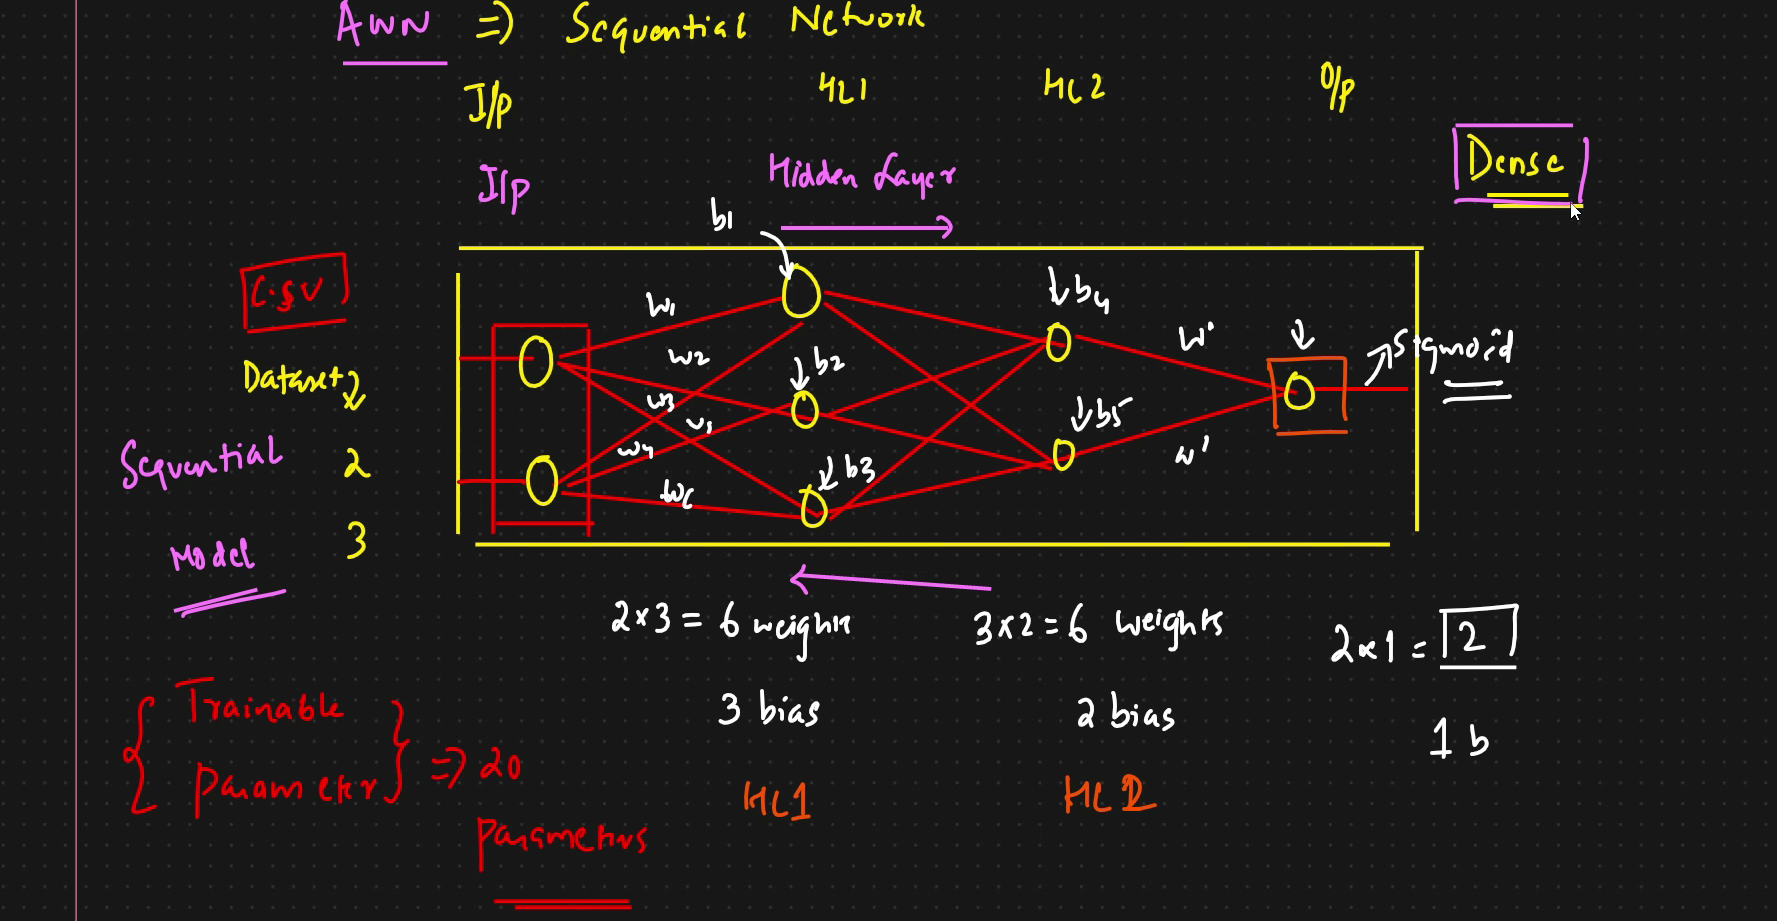

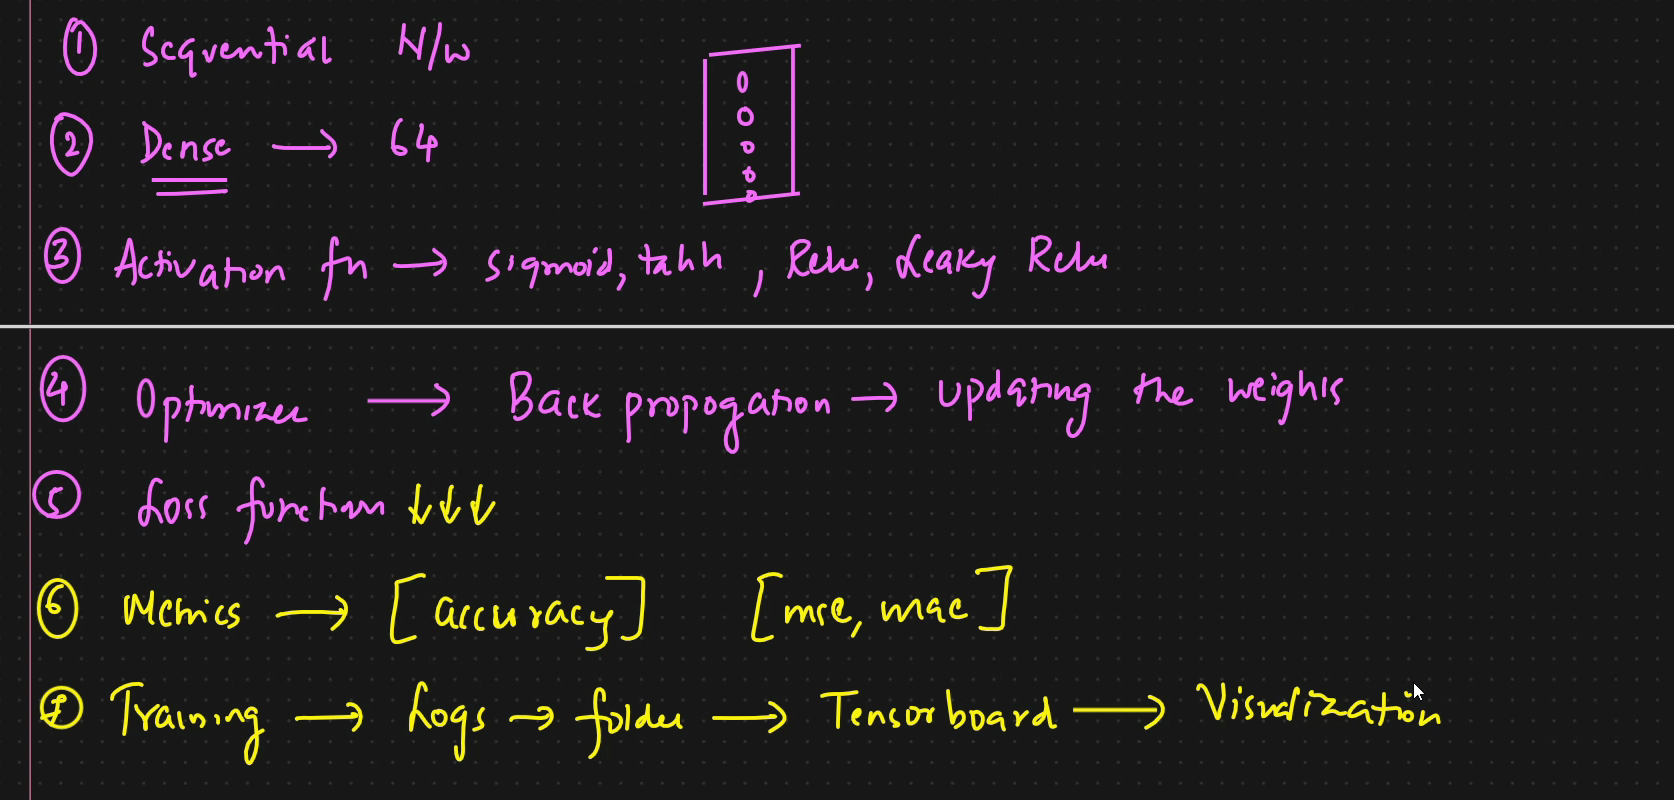

### ANN Implementation

In [158]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping,TensorBoard
import datetime

In [170]:
# X_train.shape returns (number_of_samples, number_of_features)
# X_train.shape[1] gives only the number of input features (columns).
# The comma makes it a tuple, which Keras expects for the input_shape parameter.

(X_train.shape[1],)

(12,)

In [160]:
## Build Our ANN Model
model=Sequential([
    Dense(64,activation='relu',input_shape=(X_train.shape[1],)), ## HL1 Connected wwith input layer
    Dense(32,activation='relu'), ## HL2
    Dense(1,activation='sigmoid')  ## output layer
]

)

c:\Users\Omkar\Desktop\Python\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [171]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,837 (34.52 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,892 (23.02 KB)

## Building the ANN Model

- `Sequential()` creates a neural network where layers are added one after another.
- `Dense` represents a **fully connected layer** (every neuron connects to all neurons in the previous layer).
- **Hidden Layer 1:** `Dense(64, activation='relu')`
  - 64 neurons
  - `ReLU` activation introduces non-linearity.
- **Input Shape:** `(X_train.shape[1],)`
  - Specifies the number of input features (columns).
  - Example: `(11,)` means each sample has 11 features.
- **Hidden Layer 2:** `Dense(32, activation='relu')`
  - 32 neurons with ReLU activation.
- **Output Layer:** `Dense(1, activation='sigmoid')`
  - 1 neuron for **binary classification**.
  - `Sigmoid` outputs a probability between **0 and 1**.
- `model.summary()` displays the model architecture, output shapes, and total trainable parameters.

In [172]:
import tensorflow

# Create the Adam optimizer with a learning rate of 0.01.
# The optimizer updates the model's weights during training to minimize the loss.
opt = tensorflow.keras.optimizers.Adam(learning_rate=0.01)

# Create the Binary Crossentropy loss function.
# Used for binary classification problems (output: 0 or 1).
# It measures the difference between predicted and actual values.
loss = tensorflow.keras.losses.BinaryCrossentropy()

# Display the loss function object.
loss

<LossFunctionWrapper(<function binary_crossentropy at 0x00000271B33DF880>, kwargs={'from_logits': False, 'label_smoothing': 0.0, 'axis': -1})>

In [163]:
## compile the model
model.compile(optimizer=opt,loss="binary_crossentropy",metrics=['accuracy'])

In [173]:
## Set up the Tensorboard
from tensorflow.keras.callbacks import EarlyStopping,TensorBoard

log_dir="logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorflow_callback=TensorBoard(log_dir=log_dir,histogram_freq=1)

## TensorBoard Callback

- `TensorBoard` is a visualization tool used to monitor the training process.
- `log_dir` creates a unique folder using the current date and time to store training logs.
- `TensorBoard(log_dir=log_dir, histogram_freq=1)` creates a callback that saves:
  - Training & validation loss
  - Accuracy
  - Histograms of weights and biases (`histogram_freq=1`)
- This callback is passed to `model.fit()` to log training data for visualization in TensorBoard.

In [165]:
## Set up Early Stopping
early_stopping_callback=EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True)


## Early Stopping Callback

- `EarlyStopping` stops training automatically when the model stops improving.
- `monitor='val_loss'` watches the validation loss.
- `patience=10` waits for **10 epochs** without improvement before stopping.
- `restore_best_weights=True` restores the model weights from the epoch with the **lowest validation loss**.
- Helps prevent **overfitting** and saves training time.

In [174]:
### Train the model
history=model.fit(
    X_train,y_train,validation_data=(X_test,y_test),epochs=100,
    callbacks=[tensorflow_callback,early_stopping_callback]
)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8666 - loss: 0.3226 - val_accuracy: 0.8550 - val_loss: 0.3550
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8676 - loss: 0.3224 - val_accuracy: 0.8555 - val_loss: 0.3509
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8665 - loss: 0.3219 - val_accuracy: 0.8605 - val_loss: 0.3486
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8664 - loss: 0.3180 - val_accuracy: 0.8555 - val_loss: 0.3489
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8686 - loss: 0.3158 - val_accuracy: 0.8515 - val_loss: 0.3631
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8691 - loss: 0.3148 - val_accuracy: 0.8545 - val_loss: 0.3651
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8706 - loss: 0.3124 - val_accuracy: 0.8510 - val_loss: 0.3576
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8706 - loss: 0.3092 - va

In [167]:
model.save('model.h5')

In [168]:
## Load Tensorboard Extension
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [169]:
%tensorboard --logdir logs/fit

Reusing TensorBoard on port 6006 (pid 3272), started 17:27:19 ago. (Use '!kill 3272' to kill it.)

In [ ]:
### Load the pickle file
